# Step 0: Loading Packages/Data

In [ ]:
##Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [ ]:
##Data
df = pd.read_csv("/content/cleaned_school.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4589 entries, 0 to 4588
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       4589 non-null   int64  
 1   sex                       4589 non-null   object 
 2   race                      4589 non-null   object 
 3   hispanic_origin           4589 non-null   object 
 4   education                 4589 non-null   object 
 5   current_grade             4589 non-null   object 
 6   school_type               4589 non-null   object 
 7   school_locale             4589 non-null   object 
 8   school_level              4589 non-null   object 
 9   safe_at_school            4589 non-null   int64  
 10  crime_in_neighborhood     4589 non-null   int64  
 11  name_calling              4589 non-null   int64  
 12  rumors                    4589 non-null   int64  
 13  threats                   4589 non-null   int64  
 14  physical

In [ ]:
df['fear_at_school'].describe()

,fear_at_school
count,4589.000000
mean,1.213990
std,0.503229
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000


# Step 0.5: Preparing Risk Columns

In [ ]:
## Changing crime_in_neighborhood as a binary vairable:
df['adjusted_crime_in_neighborhood'] = (df['crime_in_neighborhood'] >= 3).astype(int)
df['adjusted_crime_in_neighborhood'].value_counts().sort_index()

,count
adjusted_crime_in_neighborhood,
0,4181
1,408


0: Little to no crime \
1: Crime present

In [ ]:
##Categorizing Data:

#Verbal Bullying
verbal_bullying = ['name_calling', 'rumors', 'threats',
                   'social_exclusion', 'called_hate_speech' ]

#Physical Bullying
physical_bullying = ['physical_violence', 'forced_actions']

#Alcohol/Substances
drugs = ['alcohol_available', 'marijuana_available',
         'painkillers_available','illegal_drugs', 'other_drugs']

#Exposure to weapons/crime
crime = ['saw_students_using_drugs', 'students_with_guns',
         'graffiti', 'adjusted_crime_in_neighborhood']



#Calculating Indexs:
##SUMS:
df['verbal_bullying_sum'] = df[verbal_bullying].sum(axis=1)
df['physical_bullying_sum'] = df[physical_bullying].sum(axis=1)
df['drugs_sum'] = df[drugs].sum(axis=1)
df['exposure_sum'] = df[crime].sum(axis=1)
df['all_risks_sum'] = df[verbal_bullying + physical_bullying + drugs + crime].sum(axis=1)


##MEANS:
df['verbal_bullying_mean'] = df[verbal_bullying].mean(axis=1)
df['physical_bullying_mean'] = df[physical_bullying].mean(axis=1)
df['drugs_mean'] = df[drugs].mean(axis=1)
df['exposure_mean'] = df[crime].mean(axis=1)
df['all_risks_mean'] = df[verbal_bullying + physical_bullying + drugs + crime].mean(axis=1)


In [ ]:
df['verbal_bullying_mean'].value_counts().sort_index()

,count
verbal_bullying_mean,
0.0,3685
0.2,428
0.4,230
0.6,148
0.8,81
1.0,17


In [ ]:
df['physical_bullying_mean'].value_counts().sort_index()

,count
physical_bullying_mean,
0.0,4294
0.5,253
1.0,42


In [ ]:
df['drugs_mean'].value_counts().sort_index()

,count
drugs_mean,
0.0,3312
0.2,508
0.4,283
0.6,163
0.8,153
1.0,170


In [ ]:
df['exposure_mean'].value_counts().sort_index()

,count
exposure_mean,
0.00,2846
0.25,1076
0.50,519
0.75,128
1.00,20


In [ ]:
df.describe()

,age,safe_at_school,crime_in_neighborhood,name_calling,rumors,threats,physical_violence,forced_actions,social_exclusion,property_crime,...,verbal_bullying_sum,physical_bullying_sum,drugs_sum,exposure_sum,all_risks_sum,verbal_bullying_mean,physical_bullying_mean,drugs_mean,exposure_mean,all_risks_mean
count,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,...,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000,4589.000000
mean,14.739813,3.344955,1.707779,0.117455,0.124428,0.034212,0.049902,0.023535,0.037917,0.014382,...,0.379385,0.073436,0.659185,0.561778,1.673785,0.075877,0.036718,0.131837,0.140445,0.104612
std,1.884488,0.589973,0.672205,0.321997,0.330105,0.181794,0.217766,0.151610,0.191016,0.119073,...,0.902927,0.293883,1.304790,0.831975,2.370566,0.180585,0.146941,0.260958,0.207994,0.148160
min,12.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.062500
75%,16.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.200000,0.250000,0.187500
max,18.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,2.000000,5.000000,4.000000,14.000000,1.000000,1.000000,1.000000,1.000000,0.875000


# Step 1: Checking Distributions


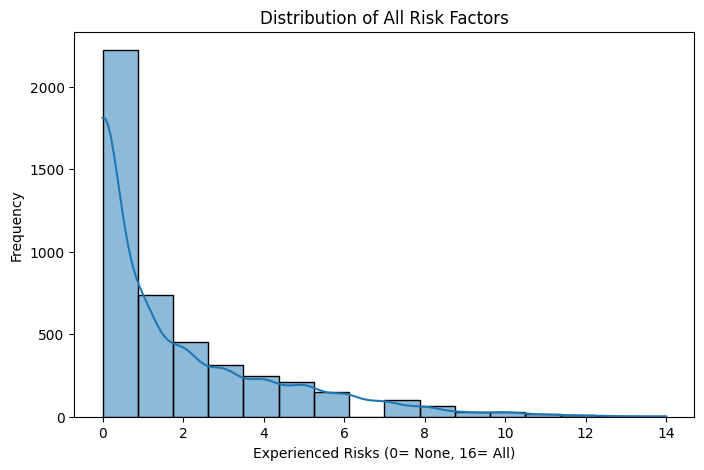

In [ ]:
## Distribution of all risks:
plt.figure(figsize=(8,5))
sns.histplot(df['all_risks_sum'], bins=16, kde=True)
plt.title('Distribution of All Risk Factors')
plt.xlabel('Experienced Risks (0= None, 16= All)')
plt.ylabel('Frequency')
plt.show()

It seems that most stidents experience little to no crime in their life. This is merely a sum of all crimes, the mean for each risk factor has been calculated.

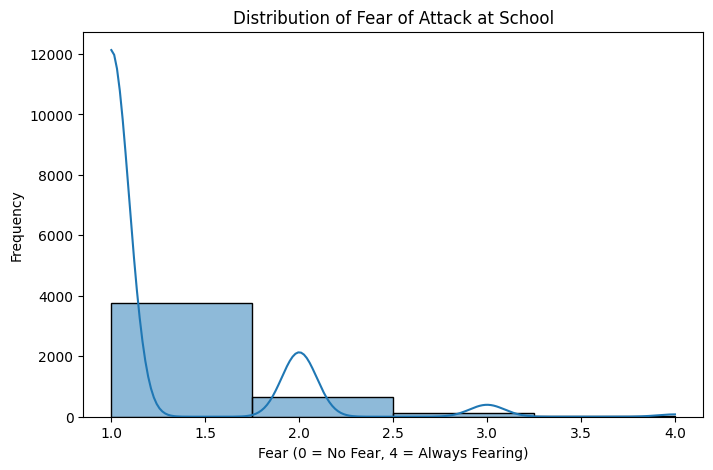

In [ ]:
## Fear of Attack at School:
plt.figure(figsize=(8,5))
sns.histplot(df['fear_at_school'], bins=4, kde=True)
plt.title('Distribution of Fear of Attack at School')
plt.xlabel('Fear (0 = No Fear, 4 = Always Fearing)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['fear_at_school'].value_counts().sort_index()

,count
fear_at_school,
1,3778
2,664
3,123
4,24


Seems our distribution for children who fear being at school is skewed to the right. Knowing this, we should do something to our target variable so it's less skewed.



In [ ]:
##Combining 1/2, 3/4 together:
df['adjusted_fear_at_school'] = (df['fear_at_school'] >= 3).astype(int)
df['adjusted_fear_at_school'].value_counts().sort_index()

,count
adjusted_fear_at_school,
0,4442
1,147


In [ ]:
## Summary
fear_summary = df["adjusted_fear_at_school"].describe()
fear_summary

,adjusted_fear_at_school
count,4589.000000
mean,0.032033
std,0.176107
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


While the data is still skewed, it will simply our problem from fitting our outcome into 4 groups to 2.

## **This will turn our earlier Multiple Linear Regression Problem now into a Multiple Logistic Regression Problem.**

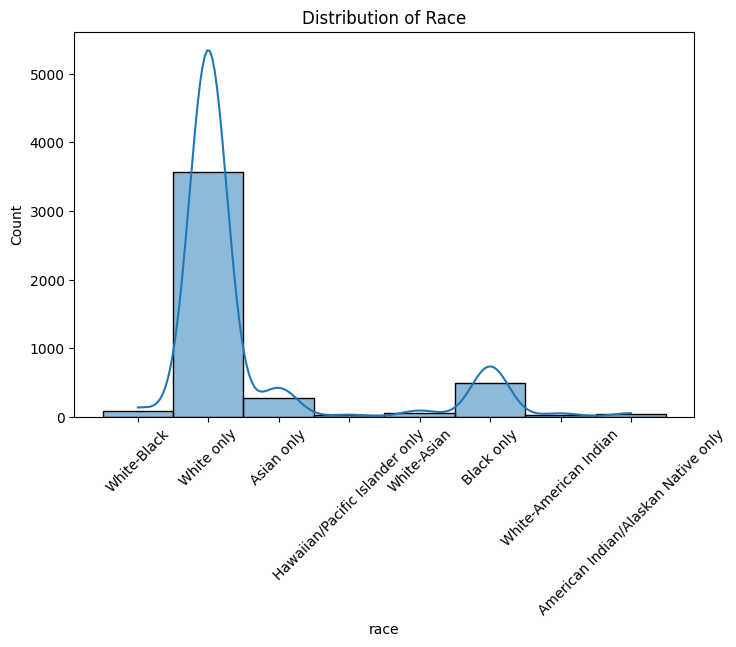

In [ ]:
##Race:
plt.figure(figsize=(8,5))
plt.title('Distribution of Race')
sns.histplot(df['race'], kde=True)
plt.xticks(rotation=45)
plt.show()


It seems most students in our dataset are white.

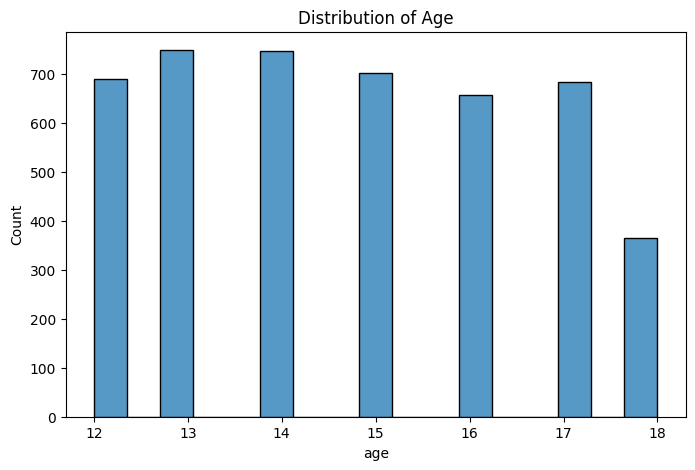

In [ ]:
##Age:
plt.figure(figsize=(8,5))
plt.title('Distribution of Age')
sns.histplot(df['age'])
plt.show()

There is a fairly uniform distribution of students aged 12-17, however there are significantly less 18 year old students.

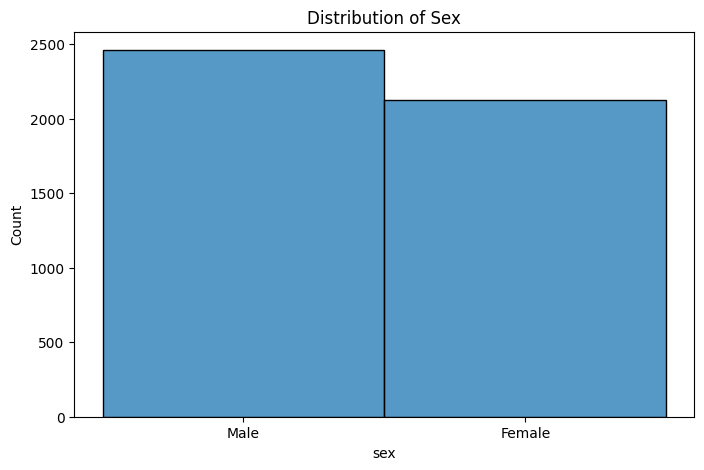

In [ ]:
##Sex:
plt.figure(figsize=(8,5))
plt.title('Distribution of Sex')
sns.histplot(df['sex'])
plt.show()

There are slightly more males in this dataset than females.

# Step 2: Checking for Outliers

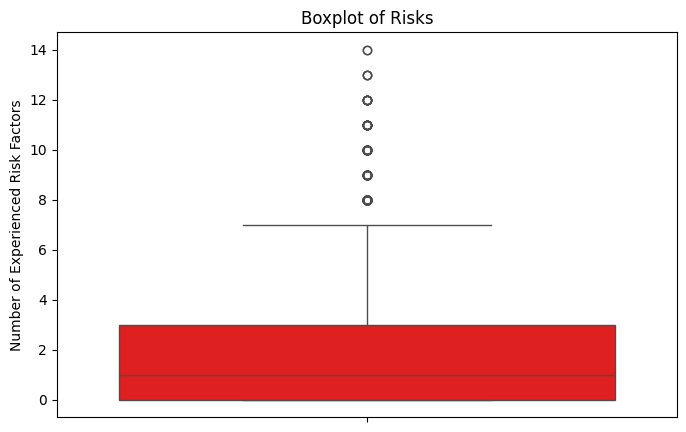

In [ ]:
##Risk Distribution:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["all_risks_sum"], color="red")
plt.title("Boxplot of Risks")
plt.ylabel("Number of Experienced Risk Factors")
plt.show()

Our data seems to be heavily right skewed, with outliers appearing from 8 onwards. This means most students who experience 8+ crimes are incredibly rare.

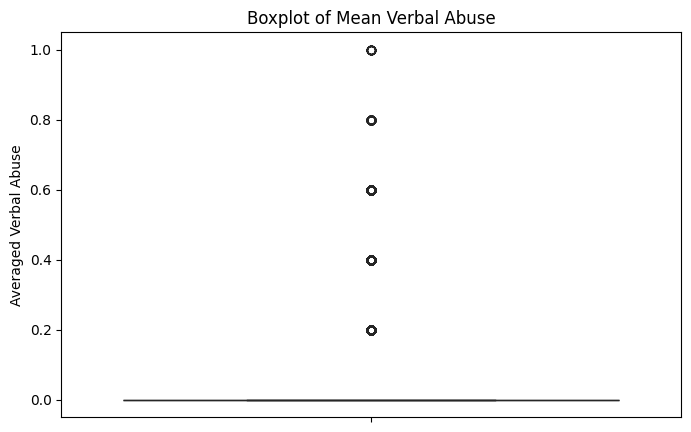

In [ ]:
## Outlier check for All Risks:
#Verbal Bullying
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["verbal_bullying_mean"], color="green")
plt.title("Boxplot of Mean Verbal Abuse")
plt.ylabel("Averaged Verbal Abuse")
plt.show()

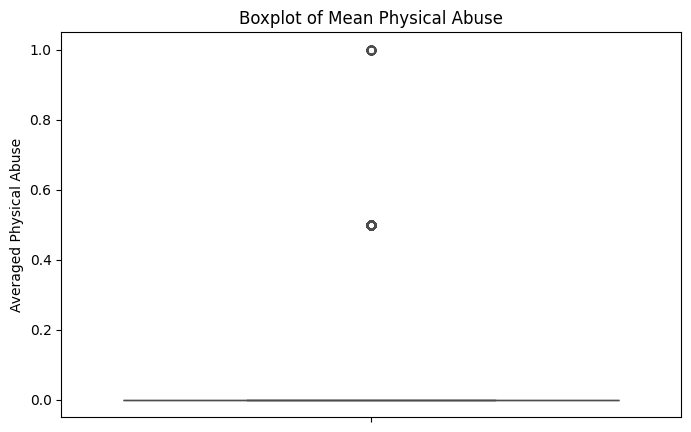

In [ ]:
#Physical Bullying
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["physical_bullying_mean"], color="orange")
plt.title("Boxplot of Mean Physical Abuse")
plt.ylabel("Averaged Physical Abuse")
plt.show()

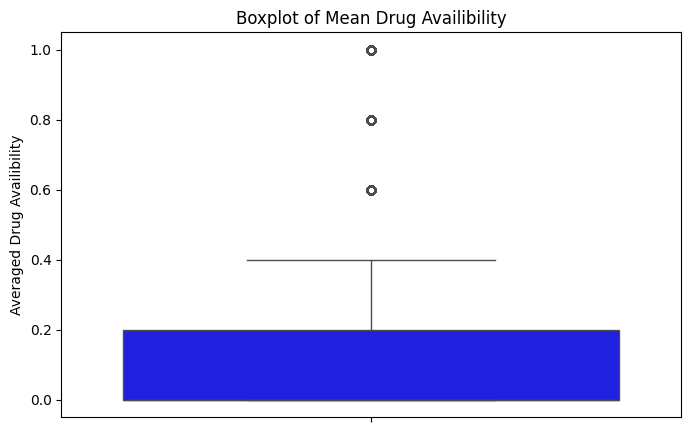

In [ ]:
#Drug Availibility
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["drugs_mean"], color="blue")
plt.title("Boxplot of Mean Drug Availibility")
plt.ylabel("Averaged Drug Availibility")
plt.show()

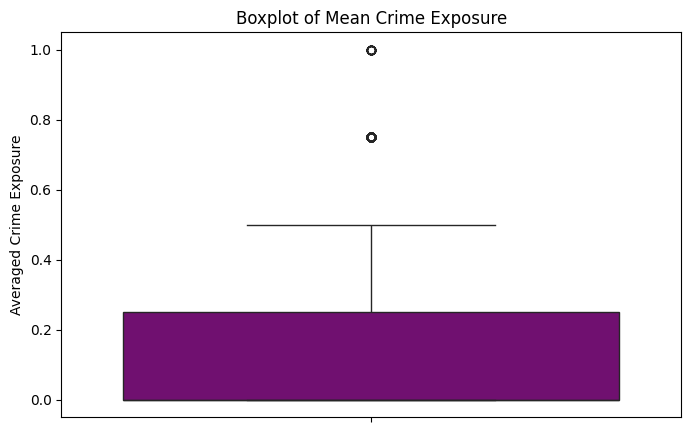

In [ ]:
#Crime Exposure:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["exposure_mean"], color="purple")
plt.title("Boxplot of Mean Crime Exposure")
plt.ylabel("Averaged Crime Exposure")
plt.show()

### Each Risk factor seems to have a few outliers. Given a large percentage of students fall into each outlier category, and because these outliers each hold useful information, we will NOT be deleting them.

# Step 3: Understanding Central Tendency

Let's perform the following task on each predictor's sum, for interpretibility:

In [ ]:
##Performing mean/median/mode on Verbal Bullying:
mean_verbal_bullying = df['verbal_bullying_sum'].mean()
print(f"Mean Verbal Bullying: {mean_verbal_bullying:.2f}")

# Median (Middle value)
median_verbal_bullying = df['verbal_bullying_sum'].median()
print(f"Median Verbal Bullying: {median_verbal_bullying:.2f}")

# Mode (Most common value)
mode_verbal_bullying = df['verbal_bullying_sum'].mode()[0]
print(f"Mode Verbal Bullying: {mode_verbal_bullying}")

Mean Verbal Bullying: 0.38
Median Verbal Bullying: 0.00
Mode Verbal Bullying: 0


In [ ]:
##Performing mean/median/mode on Physical Bullying:
mean_physical_bullying = df['physical_bullying_sum'].mean()
print(f"Mean Physical Bullying: {mean_physical_bullying:.2f}")

# Median (Middle value)
median_physical_bullying = df['physical_bullying_sum'].median()
print(f"Median Physical Bullying: {median_verbal_bullying:.2f}")

# Mode (Most common value)
mode_physical_bullying = df['physical_bullying_sum'].mode()[0]
print(f"Mode Physical Bullying: {mode_physical_bullying}")

Mean Physical Bullying: 0.07
Median Physical Bullying: 0.00
Mode Physical Bullying: 0


In [ ]:
##Performing mean/median/mode on Drugs:
mean_drugs = df['drugs_sum'].mean()
print(f"Mean Drugs: {mean_drugs:.2f}")

# Median (Middle value)
median_drugs = df['drugs_sum'].median()
print(f"Median Drugs: {median_drugs:.2f}")

# Mode (Most common value)
mode_drugs = df['drugs_sum'].mode()[0]
print(f"Mode Drugs: {mode_drugs}")

Mean Drugs: 0.66
Median Drugs: 0.00
Mode Drugs: 0


In [ ]:
##Performing mean/median/mode on Crime Exposure:
mean_crime = df['exposure_sum'].mean()
print(f"Mean Crime: {mean_crime:.2f}")

# Median (Middle value)
median_crime = df['exposure_sum'].median()
print(f"Median Crime: {median_crime:.2f}")

# Mode (Most common value)
mode_crime = df['exposure_sum'].mode()[0]
print(f"Mode Crime: {mode_crime}")

Mean Crime: 0.56
Median Crime: 0.00
Mode Crime: 0


It seems a large majority of students rarely if ever experience these risk factors. Again,  we are well aware of our skewed data, and will likely keep it as such due to outliers carrying heavily significant data.

# Step 4: Checking for NULL Values

In [ ]:
##Check:
missing_values = df.isnull().sum()
print('Number of Missing Values:', missing_values)

Number of Missing Values: age                               0
sex                               0
race                              0
hispanic_origin                   0
education                         0
current_grade                     0
school_type                       0
school_locale                     0
school_level                      0
safe_at_school                    0
crime_in_neighborhood             0
name_calling                      0
rumors                            0
threats                           0
physical_violence                 0
forced_actions                    0
social_exclusion                  0
property_crime                    0
alcohol_available                 0
marijuana_available               0
painkillers_available             0
illegal_drugs                     0
other_drugs                       0
saw_students_using_drugs          0
knife_at_school                   0
students_with_guns                0
access_to_gun                     0
ca

There are no missing values in our dataset.

# Step 5: Scatterplots

Scatterplot of feat of being attacked at school vs safety at school

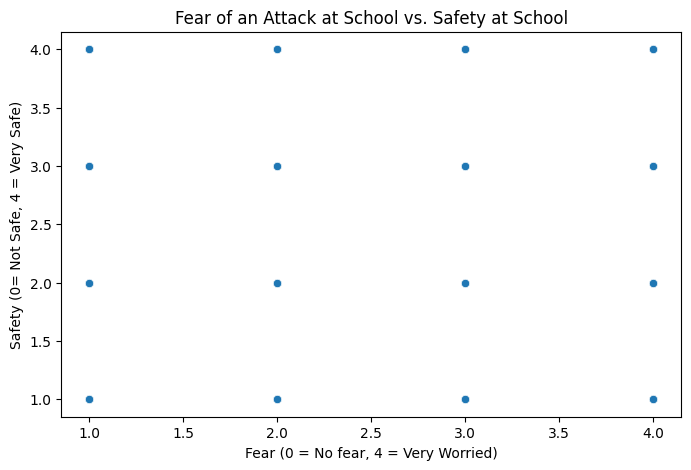

In [ ]:
#Scatterplot of feat_at_school vs safe_at_school
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['fear_at_school'], y=df['safe_at_school'])
plt.title("Fear of an Attack at School vs. Safety at School")
plt.xlabel("Fear (0 = No fear, 4 = Very Worried)")
plt.ylabel("Safety (0= Not Safe, 4 = Very Safe)")
plt.show()

Because most of our variables have so little categories, with most being integers/categorical (given a survey's nature), the following scatter plot displays this information in such a way.
Note: points do overlap, it's just hard to show on a 2d plane.

# Step 6: Correlation Heatmap

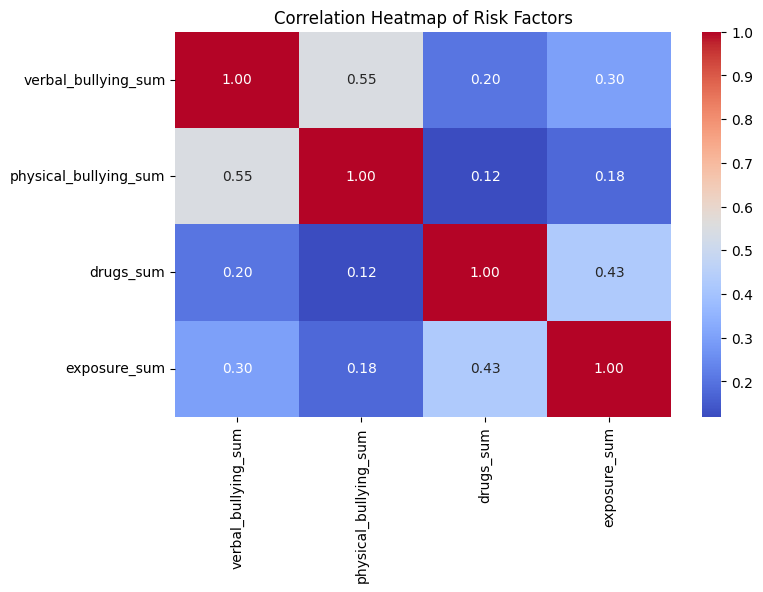

In [ ]:
##Using all of our risk factors:
risk_factors = ['verbal_bullying_sum', 'physical_bullying_sum',
                'drugs_sum', 'exposure_sum']

#Correlation HeatMap:
plt.figure(figsize=(8, 5))
sns.heatmap(df[risk_factors].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Risk Factors")
plt.show()

Physical and Verbal Bullying Seem to be fairly correlated to one another, with a correlation coeff of 0.55. This makes sense as if you were being bullied by someone, it's likely they will attempt to physically and mentally harm you.

# Step 7: Comparing Groups with Box Plots

### We will compare the total risk factors every student experiences by age.

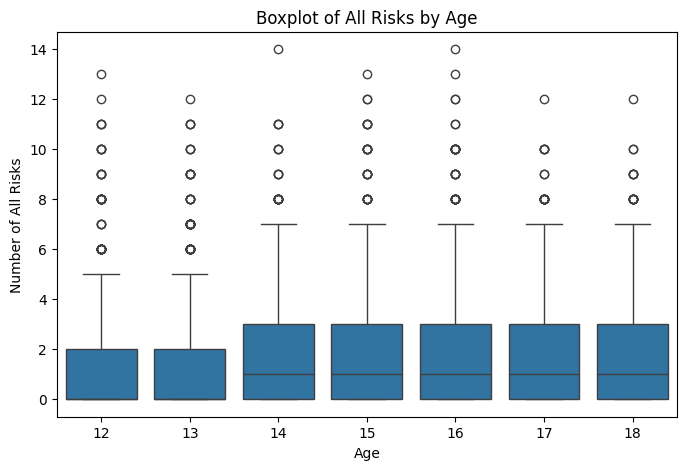

In [ ]:
##Seperated boxplot of risk factors by age
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['age'], y=df['all_risks_sum'])
plt.title('Boxplot of All Risks by Age')
plt.xlabel('Age')
plt.ylabel('Number of All Risks')
plt.show()

It seems once a student is 14+, most of students witness their first crime. Additionally, the variation of the boxplots seem fairly even, with 12 & 13 "maximum" being 5, and other ages being 7. Lastly, the ages with the most outliers seem to be students in High School.

# Step 8: Checking for Unusal Patterns

**Are there students who unsafe at school, yet have experienced little to no risk factors?**

In [ ]:
#Creating Unsafe/Safe variables:
student_feeling_unsafe = df['safe_at_school'] <=2
no_risk = df['all_risks_sum'] == 0

#Checking if there are any students who feel this way:
students = df[student_feeling_unsafe & no_risk]

#Calculating the number and percentage of students:
count = len(students)
percentage = (count / len(df)) * 100

#Results:
print(f"Number of Students Who Feel Unsafe at School, and Experienced Little to No Risks: {count}")
print(f"Percentage of Who Feel Unsafe at School, and Experienced Little to No Risks: {percentage:.2f}%")

Number of Students Who Feel Unsafe at School, and Experienced Little to No Risks: 32
Percentage of Who Feel Unsafe at School, and Experienced Little to No Risks: 0.70%


The following anomoly rarely ever happens, as if this were to occur, there could be a chance the student answered the other questions in the survey dishonestly (lied about risk factors), or feels like they are in an unsafe school enviroment.

In [ ]:
##Exporting Updated CSV:
df.to_csv('updated_cleaned_school.csv', index = False)